In [1]:
import pandas as pd

import numpy as np

df = pd.read_csv(
    "../data/processed/model_ready_data.csv"
)

print(df.shape)
df.head()

(985989, 42)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2,...,StateHoliday_c,Sales_Lag_7,Sales_Lag_14,Sales_Lag_28,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28
0,1,2,2013-01-29,3725,522,1,0,0,1270.0,0,...,0,5720.0,3900.0,0.0,4533.142857,4170.500000,4121.285714,2080.017823,1899.595898,2075.631146
1,1,3,2013-01-30,4601,560,1,0,0,1270.0,0,...,0,5578.0,4008.0,5530.0,4248.142857,4158.000000,4254.321429,2026.274696,1902.086951,1914.845455
2,1,4,2013-01-31,4709,571,1,0,0,1270.0,0,...,0,5195.0,4044.0,4327.0,4108.571429,4200.357143,4221.142857,1951.681400,1905.090008,1899.913267
3,1,5,2013-02-01,5633,658,1,0,0,1270.0,0,...,0,5586.0,4127.0,4486.0,4039.142857,4247.857143,4234.785714,1914.889329,1909.177546,1902.071860
4,1,6,2013-02-02,5970,701,1,0,0,1270.0,0,...,0,5598.0,5182.0,4997.0,4045.857143,4355.428571,4275.750000,1921.288841,1943.954681,1919.949818


In [2]:
# ------------------------------------------------------------
# Customer Lag Features
# ------------------------------------------------------------

for lag in [7, 14, 28]:
    df[f"Customers_Lag_{lag}"] = (
        df.groupby("Store")["Customers"]
          .shift(lag)
    )

df[
    [
        "Customers",
        "Customers_Lag_7",
        "Customers_Lag_14",
        "Customers_Lag_28"
    ]
].head(35)

,Customers,Customers_Lag_7,Customers_Lag_14,Customers_Lag_28
0,522,NaN,NaN,NaN
1,560,NaN,NaN,NaN
2,571,NaN,NaN,NaN
3,658,NaN,NaN,NaN
4,701,NaN,NaN,NaN
5,0,NaN,NaN,NaN
6,762,NaN,NaN,NaN
7,678,522.0,NaN,NaN
8,693,560.0,NaN,NaN
9,675,571.0,NaN,NaN


In [3]:
# ------------------------------------------------------------
# Customer Rolling Mean Features
# ------------------------------------------------------------

for window in [7, 14, 28]:
    df[f"Customers_RollingMean_{window}"] = (
        df.groupby("Store")["Customers"]
          .transform(
              lambda x: x.shift(1).rolling(window).mean()
          )
    )

df[
    [
        "Customers",
        "Customers_RollingMean_7",
        "Customers_RollingMean_14",
        "Customers_RollingMean_28",
    ]
].head(35)

,Customers,Customers_RollingMean_7,Customers_RollingMean_14,Customers_RollingMean_28
0,522,NaN,NaN,NaN
1,560,NaN,NaN,NaN
2,571,NaN,NaN,NaN
3,658,NaN,NaN,NaN
4,701,NaN,NaN,NaN
5,0,NaN,NaN,NaN
6,762,NaN,NaN,NaN
7,678,539.142857,NaN,NaN
8,693,561.428571,NaN,NaN
9,675,580.428571,NaN,NaN


In [4]:
# ------------------------------------------------------------
# Customer Rolling Std Features
# ------------------------------------------------------------

for window in [7, 14, 28]:
    df[f"Customers_RollingStd_{window}"] = (
        df.groupby("Store")["Customers"]
          .transform(
              lambda x: x.shift(1).rolling(window).std()
          )
    )

df[
    [
        "Customers",
        "Customers_RollingStd_7",
        "Customers_RollingStd_14",
        "Customers_RollingStd_28",
    ]
].head(35)

,Customers,Customers_RollingStd_7,Customers_RollingStd_14,Customers_RollingStd_28
0,522,NaN,NaN,NaN
1,560,NaN,NaN,NaN
2,571,NaN,NaN,NaN
3,658,NaN,NaN,NaN
4,701,NaN,NaN,NaN
5,0,NaN,NaN,NaN
6,762,NaN,NaN,NaN
7,678,252.457540,NaN,NaN
8,693,257.526605,NaN,NaN
9,675,262.266313,NaN,NaN


In [5]:
# Remove rows without sufficient historical context

df = df.dropna().reset_index(drop=True)

df.shape

# Retain only observations with complete
# historical forecasting features

(954769, 51)

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.to_csv(
    "../data/processed/model_ready_data_with_customer_features.csv",
    index=False
)   

In [8]:
# Keep only open stores

open_df = df[df["Open"] == 1].copy()

print(open_df.shape)

open_df["Open"].value_counts()

(792175, 51)


Open
1    792175
Name: count, dtype: int64

In [9]:
split_date = "2015-06-01"

train_df = open_df[
    open_df["Date"] < split_date
].copy()

valid_df = open_df[
    open_df["Date"] >= split_date
].copy()

print(train_df.shape)
print(valid_df.shape)

(733564, 51)
(58611, 51)


In [10]:
# Customer demand forecasting

customer_drop_cols = [
    "Sales",
    "Customers",
    "Date",

    "Sales_Lag_7",
    "Sales_Lag_14",
    "Sales_Lag_28",

    "Sales_RollingMean_7",
    "Sales_RollingMean_14",
    "Sales_RollingMean_28",

    "Sales_RollingStd_7",
    "Sales_RollingStd_14",
    "Sales_RollingStd_28"
]



In [11]:
X_train_cust = train_df.drop(columns=customer_drop_cols)
y_train_cust = train_df["Customers"]

X_valid_cust = valid_df.drop(columns=customer_drop_cols)
y_valid_cust = valid_df["Customers"]

print(X_train_cust.shape)
print(X_valid_cust.shape)

(733564, 39)
(58611, 39)


In [12]:
TARGET = "Sales"

drop_cols = [
    "Sales",
    "Customers",
    "Date",
    "Open"
]

X_train_open = train_df.drop(columns=drop_cols)
y_train_open = train_df[TARGET]

X_valid_open = valid_df.drop(columns=drop_cols)
y_valid_open = valid_df[TARGET]

In [13]:

from xgboost import XGBRegressor

xgb_open = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)


In [14]:
xgb_open.fit(X_train_open, y_train_open)

KeyboardInterrupt: 

In [ ]:
open_preds = xgb_open.predict(X_valid_open)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

In [ ]:
open_mae = mean_absolute_error(
    y_valid_open,
    open_preds
)

open_rmse = np.sqrt(
    mean_squared_error(
        y_valid_open,
        open_preds
    )
)

open_r2 = r2_score(
    y_valid_open,
    open_preds
)

print("Open Store XGBoost Results")
print("-" * 35)
print(f"MAE  : {open_mae:.2f}")
print(f"RMSE : {open_rmse:.2f}")
print(f"R²   : {open_r2:.4f}")

Open Store XGBoost Results
-----------------------------------
MAE  : 630.28
RMSE : 889.41
R²   : 0.9183


In [15]:
X_train_cust = train_df.drop(columns=customer_drop_cols)
y_train_cust = train_df["Customers"]

X_valid_cust = valid_df.drop(columns=customer_drop_cols)
y_valid_cust = valid_df["Customers"]

print(X_train_cust.shape)
print(X_valid_cust.shape)

(733564, 39)
(58611, 39)


In [16]:
from xgboost import XGBRegressor

cust_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [17]:
cust_xgb.fit(
    X_train_cust,
    y_train_cust
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [18]:
cust_preds = cust_xgb.predict(
    X_valid_cust
)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
cust_mae = mean_absolute_error(
    y_valid_cust,
    cust_preds
)

cust_rmse = np.sqrt(
    mean_squared_error(
        y_valid_cust,
        cust_preds
    )
)

cust_r2 = r2_score(
    y_valid_cust,
    cust_preds
)

print("Customer Forecast Results")
print("-" * 35)
print(f"MAE  : {cust_mae:.2f}")
print(f"RMSE : {cust_rmse:.2f}")
print(f"R²   : {cust_r2:.4f}")

Customer Forecast Results
-----------------------------------
MAE  : 52.56
RMSE : 75.45
R²   : 0.9629


In [22]:
valid_df["Predicted_Customers"] = cust_preds


In [23]:
train_pipeline = train_df.copy()
valid_pipeline = valid_df.copy()

In [24]:
valid_pipeline["Predicted_Customers"] = cust_preds

In [25]:
train_pred_customers = cust_xgb.predict(X_train_cust)
valid_pred_customers = cust_xgb.predict(X_valid_cust)

In [26]:
train_pipeline = train_df.copy()
valid_pipeline = valid_df.copy()

train_pipeline["Predicted_Customers"] = train_pred_customers
valid_pipeline["Predicted_Customers"] = valid_pred_customers

In [27]:
sales_drop_cols = [
    "Sales",
    "Date",
    "Open",
    "Customers"
]

In [28]:
X_train_pipeline = train_pipeline.drop(
    columns=sales_drop_cols
)

X_valid_pipeline = valid_pipeline.drop(
    columns=sales_drop_cols
)

y_train_pipeline = train_pipeline["Sales"]
y_valid_pipeline = valid_pipeline["Sales"]

In [29]:
print(X_train_pipeline.shape)
print(X_valid_pipeline.shape)

(733564, 48)
(58611, 48)


In [30]:

print(
    "Predicted_Customers" in X_train_pipeline.columns
)

print(
    "Customers" in X_train_pipeline.columns
)

True
False


In [31]:
pipeline_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)


In [32]:
pipeline_xgb.fit(
    X_train_pipeline,
    y_train_pipeline
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [33]:
pipeline_preds = pipeline_xgb.predict(
    X_valid_pipeline
)

In [34]:
pipeline_mae = mean_absolute_error(
    y_valid_pipeline,
    pipeline_preds
)

pipeline_rmse = np.sqrt(
    mean_squared_error(
        y_valid_pipeline,
        pipeline_preds
    )
)

pipeline_r2 = r2_score(
    y_valid_pipeline,
    pipeline_preds
)

print("Two-Stage Pipeline Results")
print("-"*35)
print(f"MAE  : {pipeline_mae:.2f}")
print(f"RMSE : {pipeline_rmse:.2f}")
print(f"R²   : {pipeline_r2:.4f}")

Two-Stage Pipeline Results
-----------------------------------
MAE  : 614.45
RMSE : 871.72
R²   : 0.9215


In [35]:
customer_importance = pd.DataFrame({
    "Feature": X_train_cust.columns,
    "Importance": cust_xgb.feature_importances_
}).sort_values("Importance", ascending=False)

customer_importance.head(20)

,Feature,Importance
35,Customers_RollingMean_28,0.411615
31,Customers_Lag_14,0.214544
34,Customers_RollingMean_14,0.137874
32,Customers_Lag_28,0.055617
33,Customers_RollingMean_7,0.048329
3,Promo,0.027825
30,Customers_Lag_7,0.019694
36,Customers_RollingStd_7,0.011693
15,IsQuarterEnd,0.010734
13,IsMonthEnd,0.006592


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

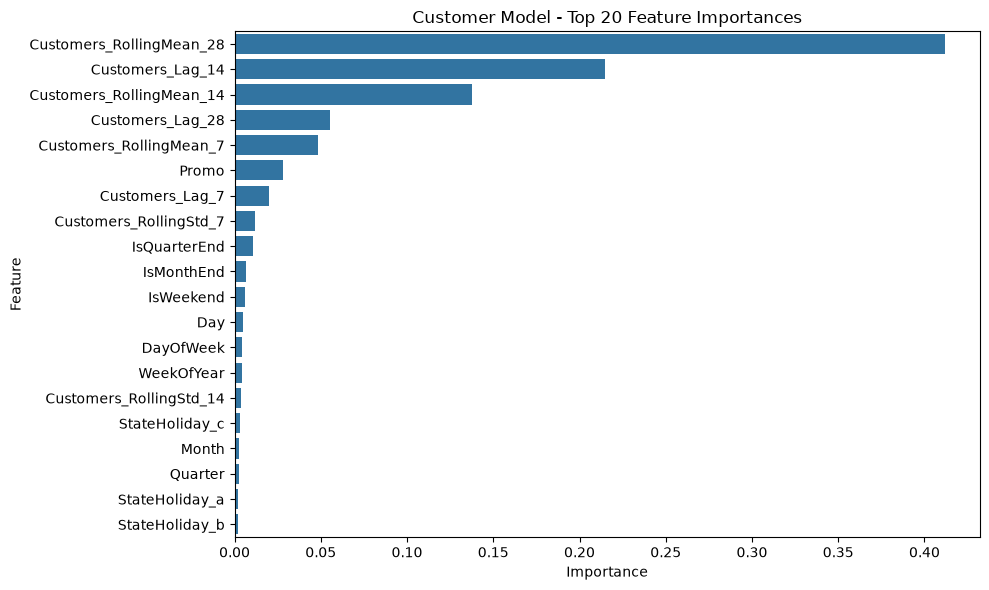

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=customer_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Customer Model - Top 20 Feature Importances")
plt.tight_layout()

plt.show()

In [38]:
sales_importance = pd.DataFrame({
    "Feature": X_train_pipeline.columns,
    "Importance": pipeline_xgb.feature_importances_
}).sort_values("Importance", ascending=False)

sales_importance.head(20)

,Feature,Importance
47,Predicted_Customers,0.298221
30,Sales_Lag_14,0.183213
2,Promo,0.075483
34,Sales_RollingMean_28,0.057488
31,Sales_Lag_28,0.046427
24,Assortment_b,0.041608
23,StoreType_d,0.039351
33,Sales_RollingMean_14,0.035659
35,Sales_RollingStd_7,0.024467
32,Sales_RollingMean_7,0.016739


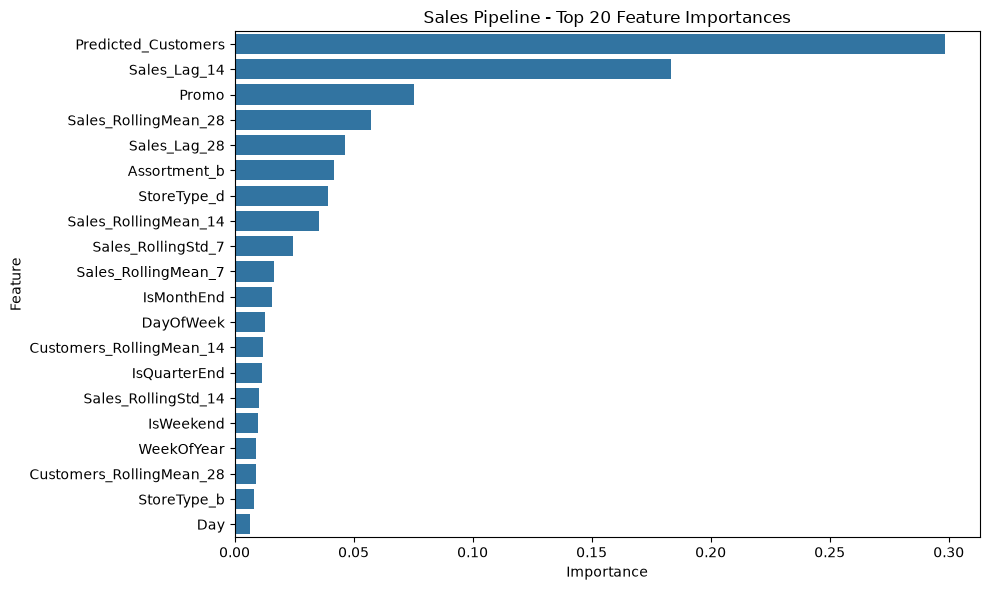

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=sales_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Sales Pipeline - Top 20 Feature Importances")
plt.tight_layout()


plt.show()

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_cust)
X_valid_scaled = scaler.transform(X_valid_cust)

print(X_train_scaled.shape)
print(X_valid_scaled.shape)

(733564, 39)
(58611, 39)


In [46]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

# -------------------------------------------------------
# Base Model
# -------------------------------------------------------

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

# -------------------------------------------------------
# Hyperparameter Search Space
# -------------------------------------------------------

param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "max_depth": [5, 6, 7, 8, 10],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3],
}


# -------------------------------------------------------
# Time Series Cross Validation
# -------------------------------------------------------

tscv = TimeSeriesSplit(n_splits=3)

# -------------------------------------------------------
# Random Search
# -------------------------------------------------------

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=25,
    scoring="r2",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

# -------------------------------------------------------
# Train
# -------------------------------------------------------

random_search.fit(X_train_pipeline, y_train_pipeline)

# -------------------------------------------------------
# Best Model
# -------------------------------------------------------

best_xgb = random_search.best_estimator_

print("\nBest Parameters")
print(random_search.best_params_)

print("\nBest CV Score")
print(random_search.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best Parameters
{'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.8}

Best CV Score
0.9360374410947164


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = best_xgb.predict(X_valid_pipeline)

mae = mean_absolute_error(y_valid_pipeline, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid_pipeline, y_pred))
r2 = r2_score(y_valid_pipeline, y_pred)

print("Tuned XGBoost Results")
print("-" * 35)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Tuned XGBoost Results
-----------------------------------
MAE  : 610.08
RMSE : 864.13
R²   : 0.9229
